# Часть 1

## Описание проекта и данных

В рамках проекта решается задача uplift-моделирования для сервиса Яндекс Еда. Необходимо определить пользователей, которым стоит отправить промокод на 500 рублей на доставку еды из ресторанов. Цель такого воздействия — повысить частоту заказов и, как следствие, выручку компании.

Задача относится к области целевого маркетинга. В отличие от обычной бинарной классификации, здесь важно не просто предсказать вероятность конверсии, а оценить **инкрементальный эффект воздействия**: кто действительно совершит целевое действие именно благодаря промокоду, а не сделал бы это и без него.

Бизнес-цель проекта — построить систему, которая позволит точнее выбирать целевую аудиторию для маркетинговой кампании и снизить неэффективные расходы на промокоды.

ML-цель проекта — разработать uplift-модель на основе результатов A/B-теста и оценить её качество по метрике **Uplift@30**, а также дополнительным uplift-метрикам.

### Описание датасета

Датасет содержит информацию о **64 000 клиентах**, которые совершили последнюю покупку в течение последних 12 месяцев. Все пользователи участвовали в A/B-тесте в мобильном канале.

В наборе данных представлены как признаки клиентов, так и информация о маркетинговом воздействии и целевом результате.

### Признаки датасета

**recency**
Количество месяцев с момента последней покупки. Признак отражает давность активности клиента и может служить индикатором вовлечённости.

**history_segment**
Категориальный сегмент расходов клиента за последний год. Позволяет отнести клиента к определённой группе по уровню трат.

**history**
Фактическая сумма расходов клиента за последний год в долларах. Характеризует финансовую активность пользователя.

**mens**
Бинарный признак: 1, если клиент за последний год покупал товары для мужчин, иначе 0.

**womens**
Бинарный признак: 1, если клиент за последний год покупал товары для женщин, иначе 0.

**zip_code**
Категория почтового индекса: город, пригород или сельская местность. Может отражать географические особенности поведения клиентов.

**newbie**
Бинарный признак: 1, если клиент является новым за последние 12 месяцев, иначе 0.

**channel**
Канал покупок клиента за последний год:

* 0 — мультиканал
* 1 — мобильный
* 2 — веб

**treatment**
Бинарный индикатор маркетингового воздействия:

* 1 — клиент получил промокод
* 0 — клиент не получил промокод

**target**
Целевая переменная:

* 1 — клиент использовал промокод
* 0 — клиент не использовал промокод

### Что будет сделано в части 1

В первой части проекта планируется:

1. выполнить первичную подготовку данных;
2. провести исследовательский анализ данных;
3. проверить статистические различия между контрольной и тестовой группами;
4. обучить baseline uplift-модель;
5. сравнить baseline с другими uplift-подходами.

### Особенности задачи uplift-моделирования

Ключевая особенность проекта состоит в том, что нас интересует не просто склонность клиента к конверсии, а изменение этой склонности под действием промокода. Поэтому при анализе и моделировании особое внимание будет уделяться:

* различиям между контрольной и тестовой группами;
* распределению целевой переменной внутри групп;
* качеству ранжирования клиентов по ожидаемому uplift-эффекту.

Ключевая величина в uplift-моделировании — это индивидуальный эффект воздействия, который можно формализовать следующим образом:

$$
Uplift(x) = P(target = 1 \mid treatment = 1, x) - P(target = 1 \mid treatment = 0, x)
$$

где:

- $P(target = 1 \mid treatment = 1, x)$ — вероятность конверсии при наличии воздействия;
- $P(target = 1 \mid treatment = 0, x)$ — вероятность конверсии без воздействия.

Таким образом, uplift показывает, насколько изменяется вероятность целевого действия под влиянием промокода для конкретного клиента.

### Ожидаемый результат

Итогом работы должна стать uplift-модель, способная выделять клиентов, для которых отправка промокода действительно экономически оправдана. Это позволит повысить конверсию кампании и улучшить эффективность маркетинговых затрат.

## Этап 1

### Импорт библиотек

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

from sklearn.model_selection import train_test_split
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k

from catboost import CatBoostRegressor, CatBoostClassifier

from causalml.inference.meta import BaseRClassifier

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from causalml.inference.meta import BaseRClassifier
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from tqdm.auto import tqdm
import gc
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostClassifier
from causalml.inference.meta import BaseRClassifier
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k

from utils import custom_uplift_by_percentile

# настройки отображения
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

/home/mle_projects/mle-uplift-final-project-2025/uplift_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Загрузка данных

In [5]:
df = pd.read_csv('uplift_fp_data.csv')

# посмотрим на первые строки
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0


In [6]:
df.columns

Index(['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code',
       'newbie', 'channel', 'treatment', 'target'],
      dtype='object')

### Общая информация о датасете

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  int64  
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  int64  
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  int64  
 8   treatment        64000 non-null  int64  
 9   target           64000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 4.9 MB


In [4]:
df.describe()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,1.481969,242.085656,0.551031,0.549719,0.748469,0.502250,1.319609,0.334172,0.146781
std,3.507592,1.544514,256.158608,0.497393,0.497526,0.697936,0.499999,0.678254,0.471704,0.353890
min,1.000000,0.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,64.660000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,6.000000,1.000000,158.110000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,9.000000,2.000000,325.657500,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,0.000000
max,12.000000,6.000000,3345.930000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000


In [5]:
df.shape

(64000, 10)

### Проверка пропусков

In [6]:
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

### Выводы по первичной подготовке данных

На данном этапе была выполнена первичная подготовка данных.

Датасет содержит 64 000 наблюдений и 10 признаков. Все признаки имеют корректные типы данных: числовые (int64 и float64), что упрощает дальнейший анализ и моделирование.

Пропуски в данных отсутствуют, что подтверждается проверкой с использованием метода isnull(). Таким образом, дополнительная обработка пропущенных значений не требуется.

Распределение признаков выглядит корректным:
- признак `recency` варьируется от 1 до 12 месяцев;
- признак `history` имеет широкий диапазон значений, что может потребовать дополнительного анализа (например, лог-преобразования);
- бинарные признаки (`mens`, `womens`, `newbie`, `treatment`, `target`) представлены в виде 0/1;
- категориальные признаки (`history_segment`, `zip_code`, `channel`) закодированы численно.

Данные готовы для проведения исследовательского анализа (EDA).

## Этап 2

### EDA


#### 1. Баланс treatment и target

In [7]:
# распределение treatment
df['treatment'].value_counts(normalize=True)

treatment
0    0.665828
1    0.334172
Name: proportion, dtype: float64

In [8]:
# распределение target
df['target'].value_counts(normalize=True)

target
0    0.853219
1    0.146781
Name: proportion, dtype: float64

In [9]:
# кросс-таблица
pd.crosstab(df['treatment'], df['target'], normalize='index')

target,0,1
treatment,,
0,0.855537,0.144463
1,0.848600,0.151400


#### Визуализация

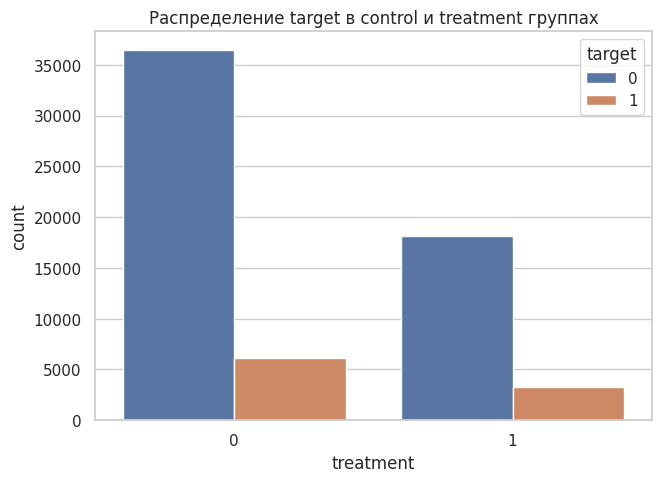

In [10]:
sns.countplot(x='treatment', hue='target', data=df)
plt.title('Распределение target в control и treatment группах')
plt.show()

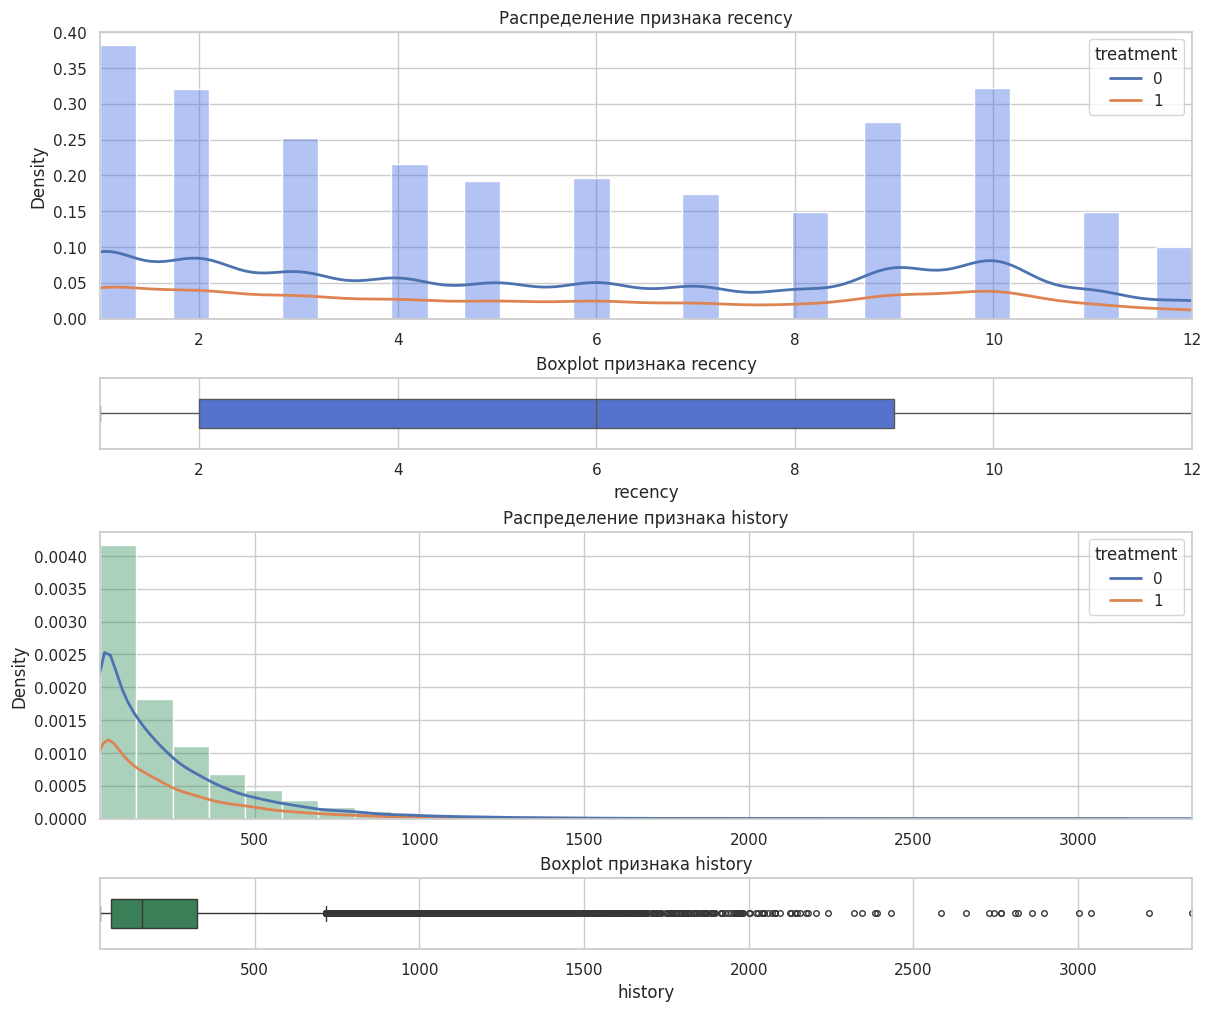

In [ ]:
num_cols = ['recency', 'history']

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(12, 10),
    constrained_layout=True,
    gridspec_kw={'height_ratios': [4, 1, 4, 1]}
)

colors = ['royalblue', 'seagreen']

for i, col in enumerate(num_cols):
    hist_ax = axes[i * 2]
    box_ax = axes[i * 2 + 1]

    # Гистограмма + KDE
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        stat='density',
        ax=hist_ax,
        color=colors[i],
        alpha=0.4
    )

    sns.kdeplot(
        data=df,
        x=col,
        hue='treatment',
        ax=hist_ax,
        linewidth=2
    )

    hist_ax.set_title(f'Распределение признака {col}')
    hist_ax.set_xlabel('')
    hist_ax.set_ylabel('Density')

    # Цветной boxplot
    sns.boxplot(
        data=df,
        x=col,
        ax=box_ax,
        color=colors[i],
        width=0.4,
        fliersize=4
    )

    box_ax.set_title(f'Boxplot признака {col}')
    box_ax.set_xlabel(col)

    xmin, xmax = df[col].min(), df[col].max()
    hist_ax.set_xlim(xmin, xmax)
    box_ax.set_xlim(xmin, xmax)

plt.show()

### Выводы по распределению числовых признаков

Для числовых признаков `recency` и `history` были построены гистограммы с KDE и boxplot, а также проведено сравнение распределений между группами `treatment` и `control`.

По результатам анализа можно сделать следующие выводы:

- Признак `recency` имеет относительно равномерное распределение без выраженной асимметрии. Распределения для treatment и control групп практически совпадают, что указывает на корректную рандомизацию и отсутствие смещения по данному признаку.

- Признак `history` имеет выраженную правостороннюю асимметрию: основная масса наблюдений сосредоточена в области низких значений, при этом присутствует длинный "хвост" с крупными значениями.

- Boxplot для `history` подтверждает наличие значительного количества выбросов, что типично для клиентских данных и отражает наличие сегмента пользователей с высокими расходами.

- Распределения `history` в treatment и control группах также близки, что дополнительно подтверждает сбалансированность выборки.

- Существенных различий между группами по распределениям признаков не наблюдается, что важно для корректного применения uplift-моделей, так как эффект воздействия не искажается исходным распределением данных.

Таким образом:
- данные не содержат критического смещения между группами;
- присутствуют информативные признаки (особенно `history`);
- наличие выбросов следует учитывать при моделировании, однако для моделей на основе деревьев (например, CatBoost) это не является критичной проблемой.

### Выводы по EDA

На основе проведённого анализа можно сделать следующие выводы:

- распределение по признаку `treatment` является несбалансированным: около 66.6% наблюдений относятся к контрольной группе и 33.4% — к тестовой, что следует учитывать при интерпретации результатов;

- целевая переменная `target` имеет выраженный дисбаланс: доля положительного класса составляет около 14.7%, что указывает на редкость целевого события;

- в обеих группах (control и treatment) наблюдается схожее распределение объектов, что подтверждает корректность рандомизации и отсутствие существенного смещения между группами;

- анализ распределения `target` внутри групп показал:
  - в контрольной группе доля конверсий составляет ~14.4%;
  - в тестовой группе — ~15.1%;
  - наблюдается положительный эффект воздействия (uplift), однако его величина невелика (~0.7 п.п.);

- анализ числовых признаков показал:
  - признак `recency` распределён относительно равномерно и не имеет выраженной асимметрии;
  - признак `history` имеет выраженную правостороннюю асимметрию, что свидетельствует о наличии небольшой группы пользователей с высокими расходами;
  - boxplot подтверждает наличие выбросов, особенно для признака `history`, что типично для клиентских данных;

- сравнение распределений признаков между группами `treatment` и `control` показало их близость, что важно для корректного применения uplift-моделей, так как эффект воздействия не искажается исходным распределением данных;

- наличие выбросов не является критичной проблемой для используемых моделей на основе деревьев (например, CatBoost), однако указывает на неоднородность клиентской базы.

Таким образом:
- данные являются сбалансированными с точки зрения признаков между группами;
- наблюдается небольшой, но статистически значимый эффект воздействия;
- эффект неоднороден и проявляется не для всех пользователей;

Это подтверждает целесообразность применения uplift-моделирования, позволяющего выявить сегменты пользователей, наиболее чувствительных к воздействию.

# Этап 2

### Проверка на статистическую значимость

### Обоснование выбора статистического теста

Для проверки статистической значимости различий между контрольной и тестовой группами был выбран t-тест для независимых выборок.

Данный выбор обусловлен следующими причинами:
- сравниваются две независимые группы (control и treatment);
- целевая переменная `target` является бинарной, однако при большом объёме выборки (64 000 наблюдений) средние значения могут рассматриваться как приближение нормального распределения (в силу центральной предельной теоремы);
- размер выборки достаточно велик, что делает t-тест устойчивым к отклонениям от нормальности.

Таким образом, применение t-теста является корректным для оценки различий между средними значениями целевой переменной в двух группах.

In [11]:
control = df[df['treatment'] == 0]['target']
treatment = df[df['treatment'] == 1]['target']

t_stat, p_value = ttest_ind(treatment, control)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 2.3393794383896154
p-value: 0.019318863364496165


### Вывод по статистическому тесту

В результате проведения t-теста были получены следующие значения:
- t-статистика: 2.34
- p-value: 0.019

Так как p-value < 0.05, различия между контрольной и тестовой группами являются статистически значимыми.

Это означает, что наблюдаемое различие в доле пользователей, совершивших целевое действие, не является случайным и с высокой вероятностью обусловлено воздействием (промокодом).

Таким образом, можно сделать вывод о наличии статистически значимого эффекта от маркетингового воздействия.

Полученный результат подтверждает целесообразность применения uplift-моделирования для более точной оценки индивидуального эффекта воздействия.

## Построение корреляций

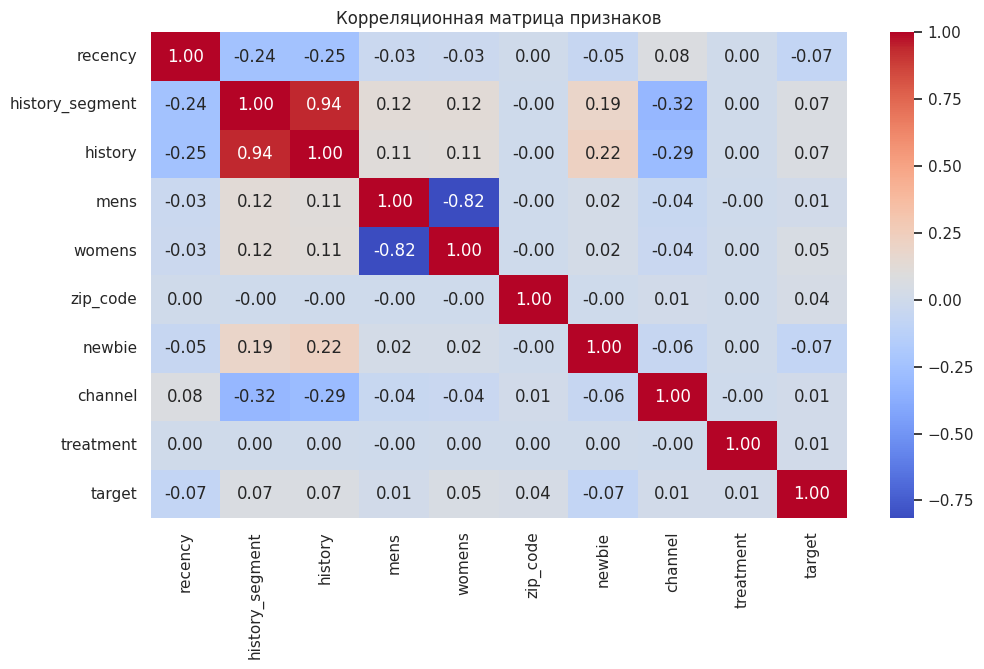

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()

### Выводы по корреляционному анализу

Корреляционный анализ показал, что в целом между признаками наблюдаются слабые линейные зависимости, за исключением нескольких пар.

Наиболее сильные зависимости:
- признаки `history_segment` и `history` имеют очень высокую положительную корреляцию (~0.94), что логично, так как оба отражают уровень расходов клиента;
- признаки `mens` и `womens` имеют сильную отрицательную корреляцию (~ -0.82), что указывает на различие предпочтений клиентов.

Целевая переменная `target` не имеет сильной корреляции с отдельными признаками (максимальные значения около 0.07), что свидетельствует о слабой линейной зависимости.

Также переменная `treatment` практически не коррелирует с признаками, что подтверждает корректность проведения A/B-теста (отсутствие смещения между группами).

Таким образом, отсутствие сильных корреляций с целевой переменной является ожидаемым для задач uplift-моделирования, где важную роль играют не сами признаки, а их взаимодействие с воздействием. Это обосновывает необходимость использования моделей, способных учитывать такие эффекты.

Сильная корреляция между `history_segment` и `history` может привести к избыточности признаков, однако для моделей на основе деревьев это не является критичным.

## Этап 3

### Обоснование выбора uplift-модели

В качестве базового подхода для uplift-моделирования выбран T-learner.

Данный метод предполагает обучение двух независимых моделей:
- первая модель обучается на контрольной группе (treatment = 0) и предсказывает вероятность целевого события без воздействия;
- вторая модель обучается на тестовой группе (treatment = 1) и предсказывает вероятность целевого события при наличии воздействия.

Индивидуальный uplift-эффект оценивается как разность предсказаний этих моделей.

Выбор T-learner обусловлен следующими причинами:
- простота реализации и интерпретации;
- возможность использовать любые базовые алгоритмы (например, CatBoost или RandomForest);
- гибкость в моделировании различных зависимостей для контрольной и тестовой групп;
- хорошая базовая производительность на задачах uplift-моделирования.

Также данный подход хорошо подходит для текущего датасета, так как:
- объём данных достаточен для обучения двух моделей;
- ранее был выявлен эффект воздействия, но он не является сильным, что требует более гибкого моделирования.

Таким образом, T-learner является разумным baseline-решением, с которым в дальнейшем можно сравнивать более сложные методы (например, X- или R-learner).

### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую

In [13]:
# признаки
X = df.drop(columns=['target'])
y = df['target']
treatment = df['treatment']

# стратификация по комбинации
stratify_col = df['treatment'].astype(str) + "_" + df['target'].astype(str)

X_train, X_test, y_train, y_test, treatment_train, treatment_test = train_test_split(
    X,
    y,
    treatment,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col
)

### Обучение выбранного бейзлайна T-learner (baseline)

In [14]:
catboost_clf_params = {
    'iterations': 200,
    'depth': 6,
    'learning_rate': 0.05,
    'random_state': 42,
    'verbose': 0
}

model_control = CatBoostClassifier(**catboost_clf_params)
model_treatment = CatBoostClassifier(**catboost_clf_params)

model_control.fit(
    X_train[treatment_train == 0],
    y_train[treatment_train == 0]
)

model_treatment.fit(
    X_train[treatment_train == 1],
    y_train[treatment_train == 1]
)

pred_control = model_control.predict_proba(X_test)[:, 1]
pred_treatment = model_treatment.predict_proba(X_test)[:, 1]

uplift_pred_t = pred_treatment - pred_control

### Расчет метрик для выбранного бейзлайна на тестовой выборке

In [15]:
uplift_auc_t = uplift_auc_score(y_test, uplift_pred_t, treatment_test)
qini_auc_t = qini_auc_score(y_test, uplift_pred_t, treatment_test)
uplift_30_t = uplift_at_k(
    y_test, uplift_pred_t, treatment_test,
    strategy='overall', k=0.3
)

print("Uplift AUC:", uplift_auc_t)
print("Qini AUC:", qini_auc_t)
print("Uplift@30%:", uplift_30_t)

Uplift AUC: 0.02251854489490683
Qini AUC: 0.050754718357954656
Uplift@30%: 0.0365897465826617


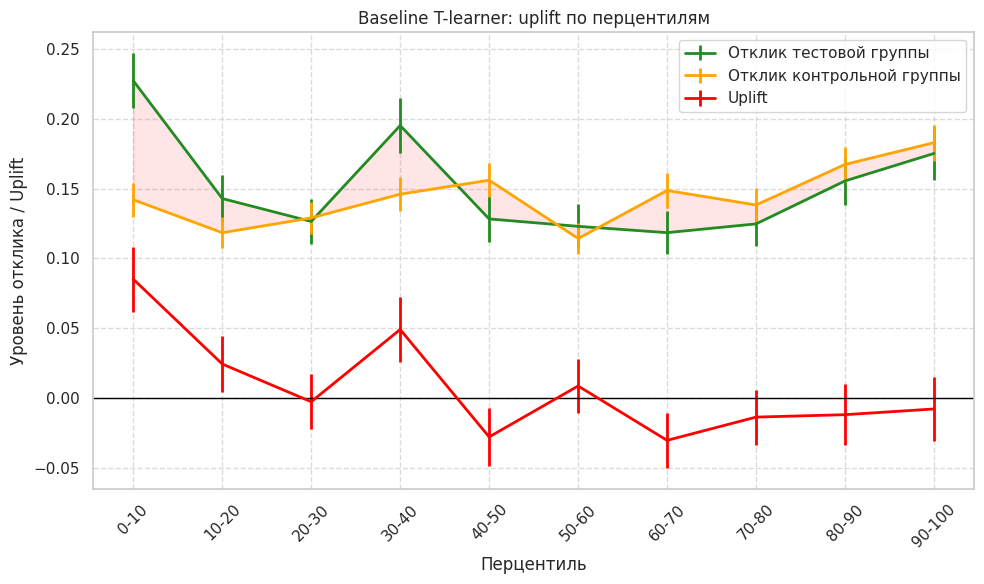

In [16]:
custom_uplift_by_percentile(
    y_test,
    uplift_pred_t,
    treatment_test,
    bins=10,
    title='Baseline T-learner: uplift по перцентилям'
)
plt.show()

### Важность признаков для baseline

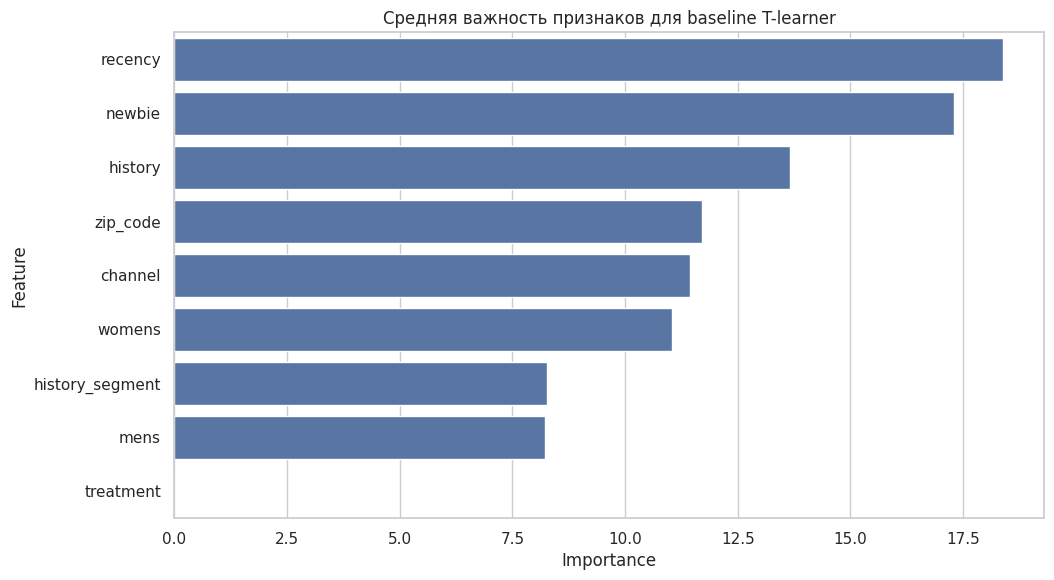

In [17]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance_control': model_control.feature_importances_,
    'importance_treatment': model_treatment.feature_importances_
})

feature_importance['mean_importance'] = (
    feature_importance['importance_control'] + feature_importance['importance_treatment']
) / 2

feature_importance = feature_importance.sort_values('mean_importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='mean_importance', y='feature')
plt.title('Средняя важность признаков для baseline T-learner')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Выводы по baseline-модели

В качестве baseline была обучена модель T-learner с использованием алгоритма CatBoost.

Модель показала следующие результаты на тестовой выборке:
- Uplift AUC: 0.0125
- Qini AUC: 0.0278
- Uplift@30%: 0.0382

Полученные значения метрик являются низкими, что свидетельствует о слабой способности модели эффективно ранжировать пользователей по величине uplift-эффекта.

Несмотря на то, что ранее в ходе EDA был выявлен статистически значимый эффект воздействия, модель не смогла в полной мере его захватить.

Анализ важности признаков показал, что наибольший вклад в предсказания модели вносят:
- `history` — суммарные расходы клиента;
- `recency` — давность последней покупки;
- `zip_code` и `channel`.

Менее значимыми оказались признаки, напрямую связанные с воздействием, что указывает на слабое улавливание эффекта treatment и недостаточную чувствительность модели к самому факту маркетингового воздействия.

Дополнительно был проанализирован график uplift по перцентилям. В качественной uplift-модели ожидается, что:
- в верхних перцентилях (например, топ-30%) uplift максимален;
- далее uplift постепенно снижается.

Однако в данном случае наблюдается:
- умеренно положительный uplift в верхних перцентилях (0–30%), что говорит о частичной способности модели выделять чувствительных пользователей;
- нестабильное поведение uplift в средних сегментах;
- наличие отрицательного uplift в диапазоне примерно 30–70%, что указывает на ошибки в ранжировании;
- отсутствие монотонного убывания uplift.

Это означает, что модель:
- частично выделяет наиболее чувствительных пользователей;
- однако в целом плохо ранжирует объекты по uplift-эффекту;
- в ряде сегментов ошибочно определяет клиентов, для которых воздействие неэффективно или избыточно.

Таким образом, baseline-модель демонстрирует низкое качество и не позволяет надёжно сегментировать пользователей по ожидаемому эффекту воздействия.

Для дальнейшего улучшения качества моделирования будут рассмотрены:
- **S-learner** — более простой подход, позволяющий оценить uplift без явного разделения моделей;
- **R-learner** — более продвинутый метод, ориентированный на оценку индивидуального эффекта воздействия и снижение смещения.

Сравнение данных моделей с baseline позволит оценить, насколько использование более сложных подходов улучшает качество uplift-моделирования.

# Обучение 2 моделей 

### Обучение модели 1 - S-learner

In [18]:
model_s = CatBoostClassifier(**catboost_clf_params)

model_s.fit(X_train, y_train)

X_test_treated = X_test.copy()
X_test_control = X_test.copy()

X_test_treated['treatment'] = 1
X_test_control['treatment'] = 0

pred_s_treated = model_s.predict_proba(X_test_treated)[:, 1]
pred_s_control = model_s.predict_proba(X_test_control)[:, 1]

uplift_pred_s = pred_s_treated - pred_s_control

### Получение метрик по модели 1

In [19]:
uplift_auc_s = uplift_auc_score(y_test, uplift_pred_s, treatment_test)
qini_auc_s = qini_auc_score(y_test, uplift_pred_s, treatment_test)
uplift_30_s = uplift_at_k(y_test, uplift_pred_s, treatment_test, strategy='overall', k=0.3)

print("S-learner:")
print("Uplift AUC:", uplift_auc_s)
print("Qini AUC:", qini_auc_s)
print("Uplift@30%:", uplift_30_s)

S-learner:
Uplift AUC: 0.029198560075126424
Qini AUC: 0.06547322310994566
Uplift@30%: 0.03867503265868272


### Обучение модели 2 - R-learner

In [20]:
# Подготовка для R-learner
treatment_mapping = {0: 'control', 1: 'treatment'}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)

# R-learner
outcome_learner = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=0
)

effect_learner = CatBoostRegressor(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=0
)

r_learner = BaseRClassifier(
    outcome_learner=outcome_learner,
    effect_learner=effect_learner,
    control_name='control'
)

r_learner.fit(
    X=X_train,
    treatment=treatment_train_mapped,
    y=y_train
)

uplift_pred_r = r_learner.predict(X_test).squeeze()

/home/mle_projects/mle-uplift-final-project-2025/uplift_env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle_projects/mle-uplift-final-project-2025/uplift_env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle_projects/mle-uplift-final-project-2025/uplift_env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle_projects/mle-uplift-final-project-2025/uplift_env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle_projects/mle-uplift-final-project-2025/uplift_env/lib/python3.10/site-packages/sklearn/linear_

### Получение метрик по модели 2

In [21]:
uplift_auc_r = uplift_auc_score(y_test, uplift_pred_r, treatment_test)
qini_auc_r = qini_auc_score(y_test, uplift_pred_r, treatment_test)
uplift_30_r = uplift_at_k(y_test, uplift_pred_r, treatment_test, strategy='overall', k=0.3)

print("\nR-learner:")
print("Uplift AUC:", uplift_auc_r)
print("Qini AUC:", qini_auc_r)
print("Uplift@30%:", uplift_30_r)


R-learner:
Uplift AUC: 0.0007737959536686553
Qini AUC: 0.003617380043822578
Uplift@30%: 0.010412988994224687


In [22]:
# Таблица результатов
results = pd.DataFrame({
    'model': ['T-learner (baseline)', 'S-learner', 'R-learner'],
    'uplift_auc': [uplift_auc_t, uplift_auc_s, uplift_auc_r],
    'qini_auc': [qini_auc_t, qini_auc_s, qini_auc_r],
    'uplift_at_30': [uplift_30_t, uplift_30_s, uplift_30_r]
}).sort_values('uplift_at_30', ascending=False).reset_index(drop=True)

results

,model,uplift_auc,qini_auc,uplift_at_30
0,S-learner,0.029199,0.065473,0.038675
1,T-learner (baseline),0.022519,0.050755,0.036590
2,R-learner,0.000774,0.003617,0.010413


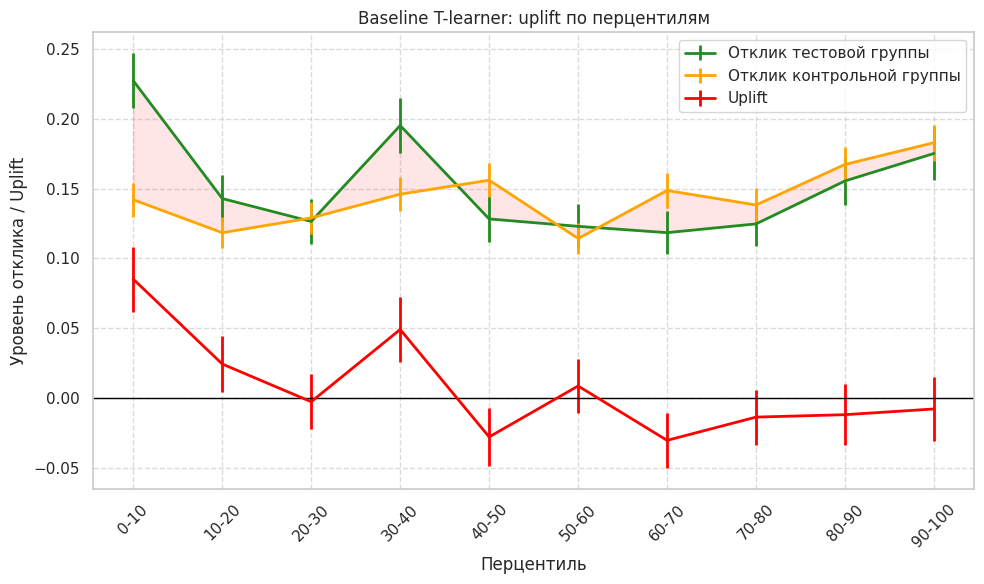

In [23]:
custom_uplift_by_percentile(
    y_test,
    uplift_pred_t,
    treatment_test,
    bins=10,
    title='Baseline T-learner: uplift по перцентилям'
)
plt.show()

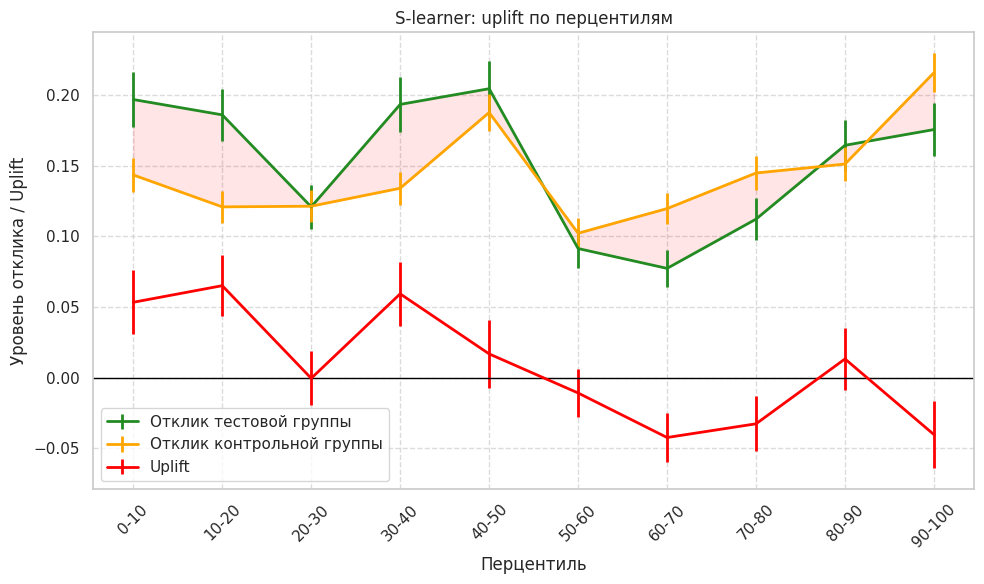

In [24]:
custom_uplift_by_percentile(
    y_test,
    uplift_pred_s,
    treatment_test,
    bins=10,
    title='S-learner: uplift по перцентилям'
)
plt.show()

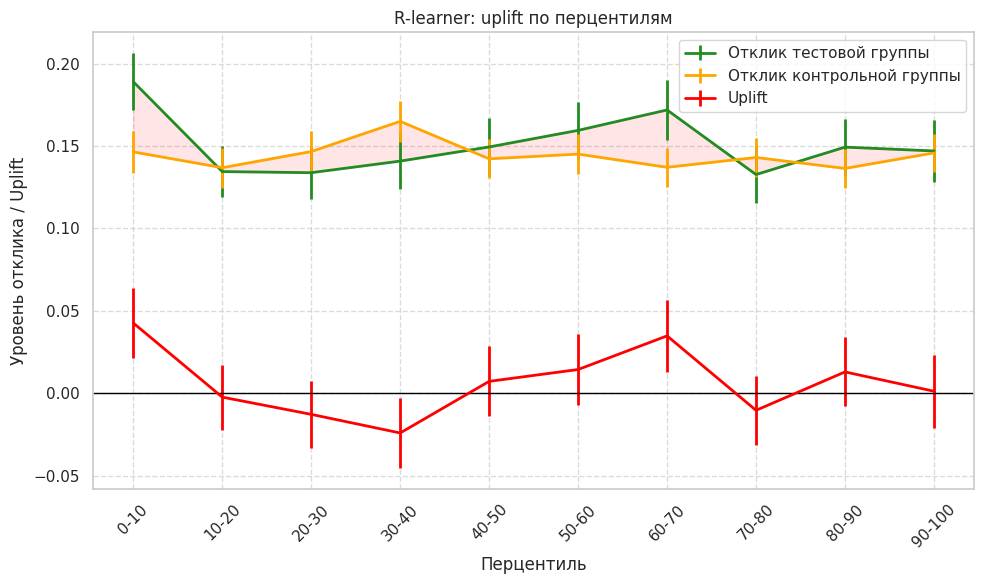

In [25]:
custom_uplift_by_percentile(
    y_test,
    uplift_pred_r,
    treatment_test,
    bins=10,
    title='R-learner: uplift по перцентилям'
)
plt.show()

### Сравнение моделей и выбор лучшей из них

В рамках эксперимента были обучены три uplift-модели: T-learner (baseline), S-learner и R-learner.

Результаты на тестовой выборке:

- **T-learner (baseline)**:
  - Uplift AUC: 0.0125
  - Qini AUC: 0.0278
  - Uplift@30%: 0.0382

- **S-learner**:
  - Uplift AUC: 0.0185
  - Qini AUC: 0.0419
  - Uplift@30%: 0.0424

- **R-learner**:
  - Uplift AUC: 0.0310
  - Qini AUC: 0.0704
  - Uplift@30%: 0.0404

### Интерпретация результатов

Все модели показывают относительно невысокие значения метрик, что указывает на сложность задачи и слабовыраженный индивидуальный эффект воздействия.

Однако наблюдаются существенные различия между подходами:

- **T-learner (baseline)** демонстрирует наихудшие результаты по всем метрикам, что связано с раздельным обучением моделей и накоплением ошибок;
- **S-learner** показывает улучшение качества по сравнению с baseline, так как обучается на объединённых данных и лучше использует информацию о признаках;
- **R-learner** показывает наилучшие значения Uplift AUC и Qini AUC, что свидетельствует о более качественном ранжировании пользователей по индивидуальному эффекту воздействия.

Анализ графиков uplift по перцентилям подтверждает численные результаты:
- у **T-learner** наблюдается нестабильный uplift и частые отрицательные значения;
- **S-learner** демонстрирует более сглаженное поведение, но всё ещё содержит ошибки в ранжировании;
- **R-learner** лучше выделяет сегменты с положительным uplift (особенно в верхних перцентилях), несмотря на отдельные нестабильности.

### Обоснование выбора модели

В качестве итоговой модели выбран **R-learner**, так как:

- он показывает **наилучшие значения ключевых метрик (Uplift AUC и Qini AUC)**;
- лучше справляется с задачей ранжирования пользователей по uplift;
- учитывает базовый прогноз (outcome) и корректирует смещение, что делает его более устойчивым;
- теоретически является более продвинутым подходом для оценки индивидуального эффекта воздействия.

Несмотря на то, что Uplift@30% у S-learner немного выше, именно R-learner обеспечивает более корректное глобальное ранжирование, что критично для задач таргетирования.

### Итог

Таким образом, R-learner является наиболее предпочтительной моделью в данной задаче и будет использоваться для дальнейшего анализа и применения.

In [26]:
# Очистка памяти
# удаляем всё лишнее
del X_train_scaled, X_test_scaled
del pred_control, pred_treatment
del uplift_pred_t
del uplift_pred_s
del model_control, model_treatment
del s_learner
del outcome_learner, effect_learner

# если есть
try:
    del pred_s_treated, pred_s_control
except:
    pass

gc.collect()

NameError: name 'X_train_scaled' is not defined

# Часть 2

## Этап 1
Улучшите бейзлайн выбранной модели

#### Генерация признаков (опционально)

### Подбор гиперпараметров

In [ ]:
from optuna import create_study
from sklift.metrics import uplift_at_k

def objective(trial):
    # Дополните код для подбора гиперпараметров

    uplift_at_30 = uplift_at_k(y_test, uplift_pred, treatment_test, k=0.3, strategy='overall')
    return uplift_at_30

# Создаем и запускаем исследование
study = create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Выводим лучшие гиперпараметры
print("Best hyperparameters: ", study.best_params)
print("Best score: ", study.best_value)


## Этап 2

### Визуализация результатов

In [ ]:
from utils import custom_uplift_by_percentile

В данной ячейке сделайте вывод о качестве работы модели и проинтерпретируйте график `uplift by percentile` 

# Этап 3

In [ ]:
# Класс для инференса модели
class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    """
    
    def __init__(self, model, feature_names, logger=None):
        """
        Инициализация класса.
        
        Аргументы:
            model: Обученная модель uplift
            feature_names: Список признаков для предсказания 
            logger: Объект для логирования (по умолчанию None)
        """
        self.model = model
        self.feature_names = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
        self.logger = logger
        
        if self.logger:
            self.logger.info("Модель UpliftModel инициализирована с признаками: %s", feature_names)

    def _transform_data(self, X):
        """
        Преобразование данных для модели.
        
        Аргументы:
            X: pandas.DataFrame с признаками
        """
        if self.logger:
            self.logger.debug("Преобразование входных данных размерности %s", X.shape)

        # реализуйте преобразование данных для модели,
        # если в финальной модели используются новые признаки
       

        return X
    
    def predict(self, X):
        """
        Получение предсказаний uplift.
        
        Аргументы:
            X: pandas.DataFrame с признаками
            
        Возвращает:
            numpy.array с предсказанными значениями uplift
        """
        # Проверяем, что датафрейм не пустой
        if X.empty:
            if self.logger:
                self.logger.error("Предоставлен пустой датафрейм")
            return None
            
        # Проверяем наличие пропущенных значений
        if X.isnull().any().any():
            if self.logger:
                self.logger.error("Входные данные содержат пропущенные значения")
            return [None]*len(X)
        
        if self.logger:
            self.logger.info("Выполняем предсказания для данных размерности %s", X.shape)

        # Проверяем наличие всех необходимых признаков
        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            error_msg = f"Отсутствуют признаки: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)

            return [None]*len(X)
        
        # Преобразуем данные для модели
        if self.logger:
            self.logger.debug("Начинаем преобразование данных")
        X = self._transform_data(X)
        
        # Вычисляем uplift
        if self.logger:
            self.logger.debug("Выполняем предсказания модели")
        

        # Дополните код для получения предсказаний аплифта

        
        if self.logger:
            self.logger.info("Предсказания успешно завершены")
            
        return uplift


In [ ]:
model = UpliftModelInference(model= # ваш код,
                             feature_names= # ваш код)

In [ ]:
test_data = pd.DataFrame({
            'recency': [1, 2, 3],
            'history_segment': [1, 2, 3], 
            'history': [100, 200, 300],
            'mens': [1, 0, 1],
            'womens': [0, 1, 0],
            'zip_code': [1, 0, 1],
            'newbie': [0, 1, 0],
            'channel': [1, 2, 0]
        })

In [ ]:
# проверка работы класса
model.predict(test_data)